# Gold Price Prediction

## Objective
Build a machine learning model to predict gold prices using historical financial indicators.

## Dataset
- Date
- SPX
- GLD
- USO
- SLV
- EUR/USD

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import pickle

In [62]:
df=pd.read_csv("gld_price_data.csv")
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [63]:
df.shape

(2290, 6)

In [64]:
# Checking the dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [65]:
df["Date"]=pd.to_datetime(df["Date"])

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [67]:
# Checking for missing values
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [68]:
# Checking duplicate values
df.duplicated().sum()

np.int64(0)

In [69]:
# Statistical Measure
df.describe(include="number")

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


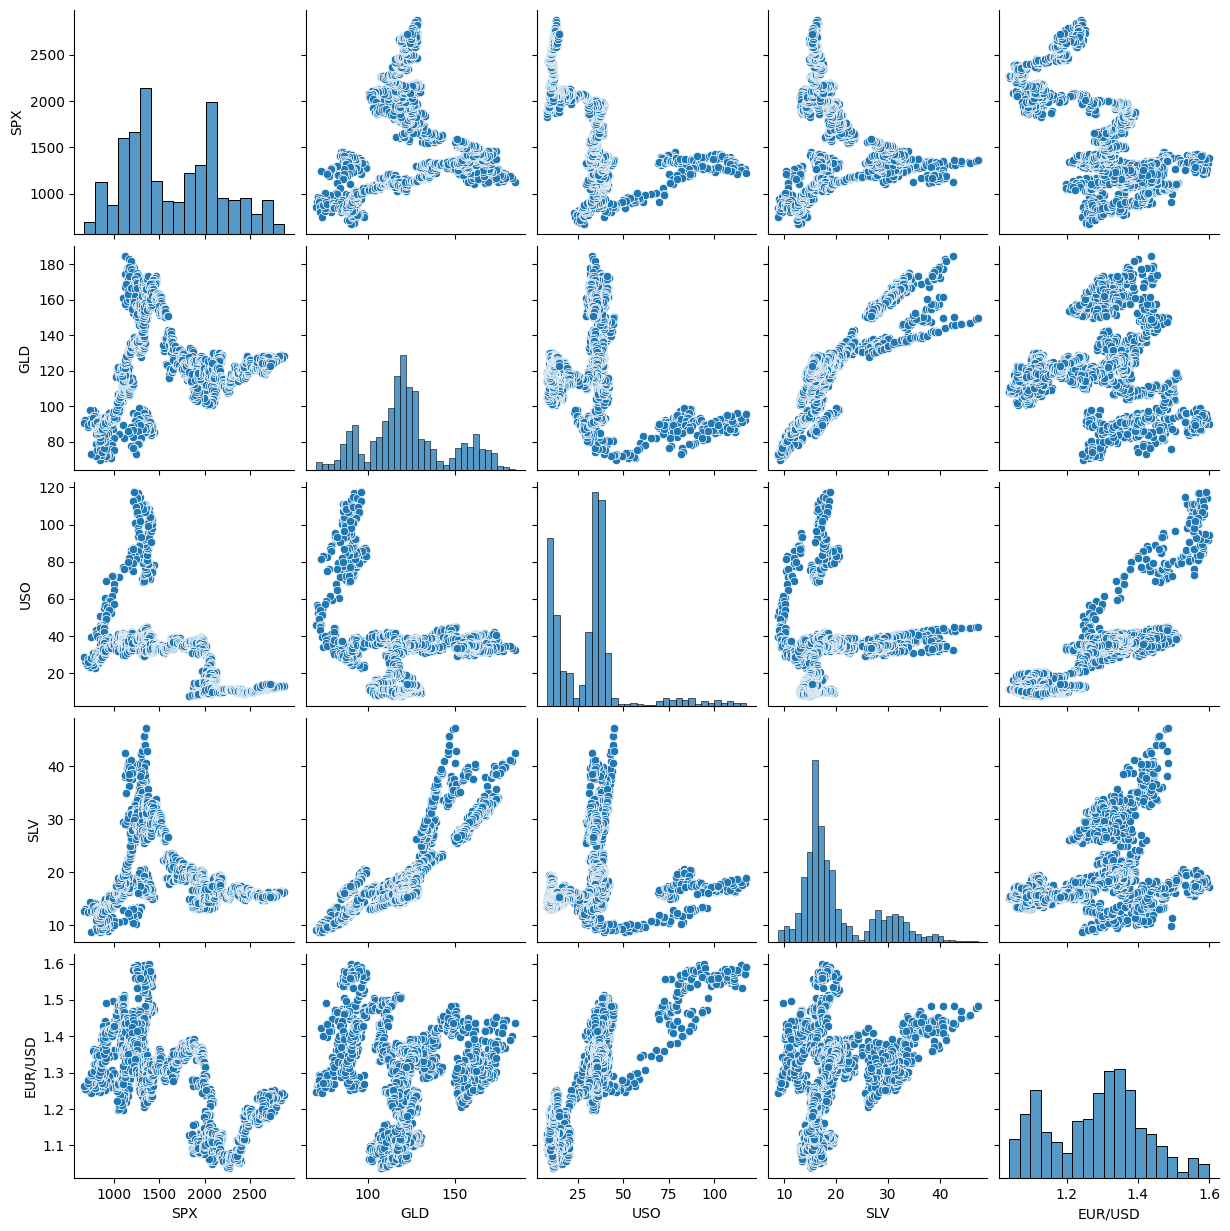

In [70]:
sns.pairplot(df)

<Axes: >

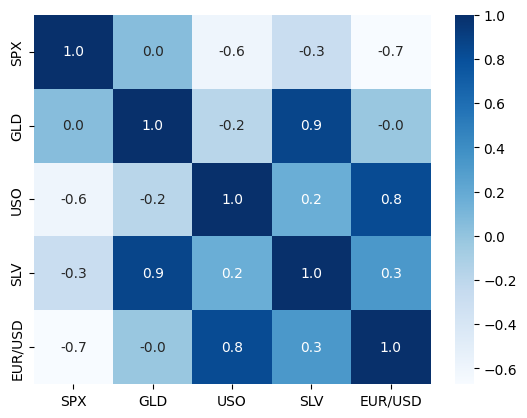

In [71]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt="0.1f",cmap="Blues")

In [72]:
df.corr()["GLD"]

Date       0.209118
SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64

<Axes: ylabel='GLD'>

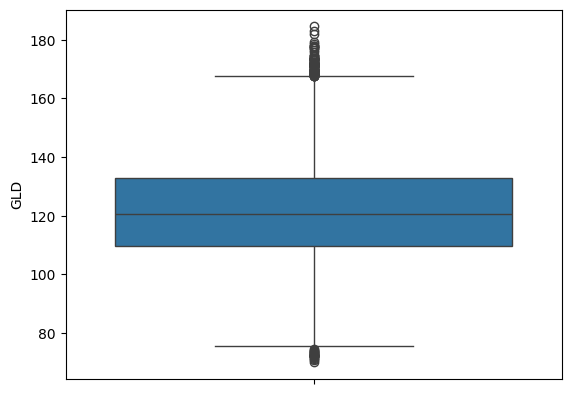

In [73]:
sns.boxplot(df["GLD"])

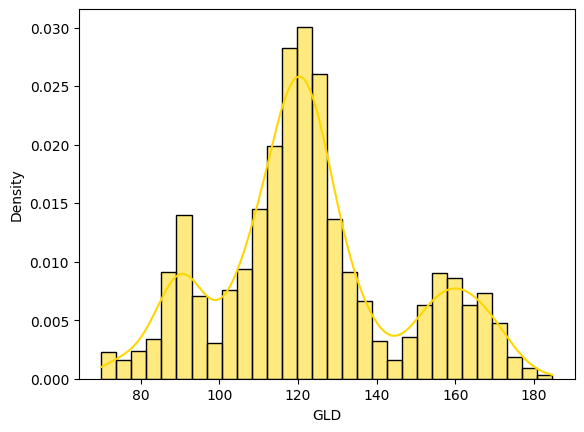

In [74]:
#Checking the distribution of GLD price
sns.histplot(df["GLD"],kde=True,stat="density",bins=30,color="gold")
plt.show()

In [75]:
df.drop("Date",axis=1,inplace=True)

- The Date column is removed because it is not directly usable by traditional regression models in its raw form.

In [76]:
df.shape

(2290, 5)

In [77]:
df.columns

Index(['SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

In [78]:
X=df.drop("GLD",axis=1)
y=df["GLD"]

**Splitting into Training and Test data**

In [79]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Model Training**

**Linear Regression**

In [80]:
lin=LinearRegression()
lin.fit(X_train,y_train)

LinearRegression()

In [81]:
y_pred_lin=lin.predict(X_test)

In [82]:
r_squared_error=r2_score(y_test,y_pred_lin)
mae=mean_absolute_error(y_test,y_pred_lin)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_lin))

In [83]:
print("R Squared Error: ",r_squared_error)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",rmse)

R Squared Error:  0.8975640982991402
Mean Absolute Error:  5.6959006442692885
Root Mean Squared Error:  7.494370835167287


**Compare between Actual and Predicted Values**

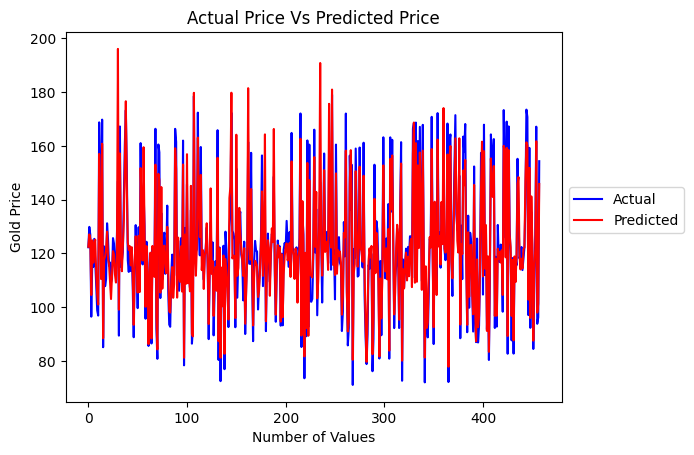

In [84]:
plt.plot(y_test.values,color="blue",label="Actual")
plt.plot(y_pred_lin,color="red",label="Predicted")
plt.title("Actual Price Vs Predicted Price")
plt.xlabel("Number of Values")
plt.ylabel("Gold Price")
plt.legend(bbox_to_anchor=(1,0.6))
plt.show()

**Random Forest Regressor**

In [98]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [99]:
y_pred_rf=rf.predict(X_test)

In [100]:
r_squared_error=r2_score(y_test,y_pred_rf)
mae=mean_absolute_error(y_test,y_pred_rf)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_rf))

In [101]:
print("R Squared Error: ",r_squared_error)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",rmse)

R Squared Error:  0.9900245384549384
Mean Absolute Error:  1.2356137487336276
Root Mean Squared Error:  2.3387057370209563


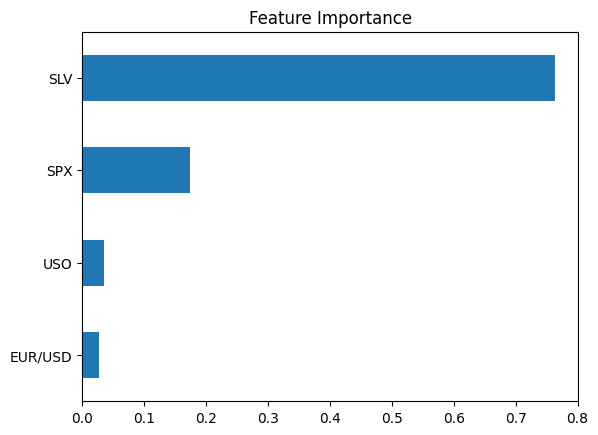

In [102]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

**Compare between Actual and Predicted Values**

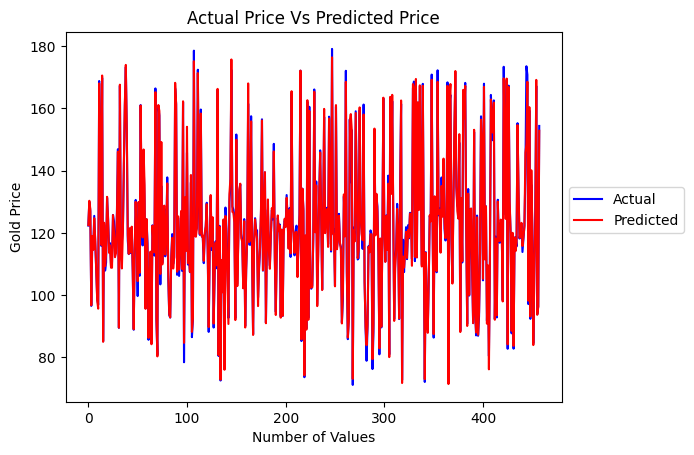

In [103]:
plt.plot(y_test.values,color="blue",label="Actual")
plt.plot(y_pred_rf,color="red",label="Predicted")
plt.title("Actual Price Vs Predicted Price")
plt.xlabel("Number of Values")
plt.ylabel("Gold Price")
plt.legend(bbox_to_anchor=(1,0.6))
plt.show()

**Decision Tree Regressor**

In [104]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [105]:
y_pred_dt=dt.predict(X_test)

In [106]:
r_squared_error=r2_score(y_test,y_pred_dt)
mae=mean_absolute_error(y_test,y_pred_dt)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_dt))

In [107]:
print("R Squared Error: ",r_squared_error)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",rmse)

R Squared Error:  0.9847304499139271
Mean Absolute Error:  1.476287991266375
Root Mean Squared Error:  2.893491440985496


**Compare between Actual and Predicted Values**

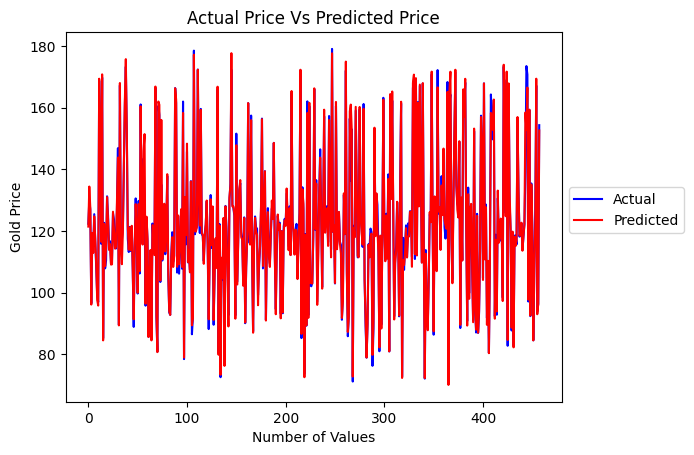

In [108]:
plt.plot(y_test.values,color="blue",label="Actual")
plt.plot(y_pred_dt,color="red",label="Predicted")
plt.title("Actual Price Vs Predicted Price")
plt.xlabel("Number of Values")
plt.ylabel("Gold Price")
plt.legend(bbox_to_anchor=(1,0.6))
plt.show()

In [109]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R² Score": [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lin),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lin)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ]
})

comparison = comparison.round(4)
comparison = comparison.sort_values(by="R² Score", ascending=False)

comparison

,Model,R² Score,MAE,RMSE
2,Random Forest,0.9900,1.2356,2.3387
1,Decision Tree,0.9847,1.4763,2.8935
0,Linear Regression,0.8976,5.6959,7.4944


In [110]:
with open("rf_model.pkl","wb") as f:
    pickle.dump(rf,f)

## Conclusion

Among all models tested, Random Forest achieved the highest R² score and the lowest MAE, making it the best model for predicting gold prices.